In [ ]:
#Irem_Dogruoglu_7061348_Lizzie_Schmitz_7056551
#References:
#1.https://matplotlib.org/stable/tutorials/introductory/pyplot.html
#2.https://github.com/gnina/gnina
#3.https://github.com/RMeli/gnina-torch
#4.https://github.com/degrado-lab/PoseBusters-Benchmark
#This notebook creates outputs for docking, retraining, and analysis with GNINA-Torch.
#It loads the outputs from the main pipeline and visualizes the key metrics on the posebusters dataset benchmark.

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np

#Getting the right directories for inputs and outputs. 
RESULTS_PT = Path("results")
MODEL_DIR = RESULTS_PT / "gninatorch_training"
REDO_MODEL_DIR = RESULTS_PT / "posebusters_filtered"
PLOTS_DIR = RESULTS_PT / "plots"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)

#Creating loop to generate metrics for all trained model directories.
trained_model_dirs = [d for d in MODEL_DIR.iterdir() if d.is_dir()]

MODEL_DIR, REDO_MODEL_DIR, PLOTS_DIR, trained_model_dirs

(PosixPath('results/gninatorch_training'),
 PosixPath('results/proto_test_retrained'),
 PosixPath('results/plots'),
 [PosixPath('results/gninatorch_training/default2018_seed1'),
  PosixPath('results/gninatorch_training/dense_seed1')])

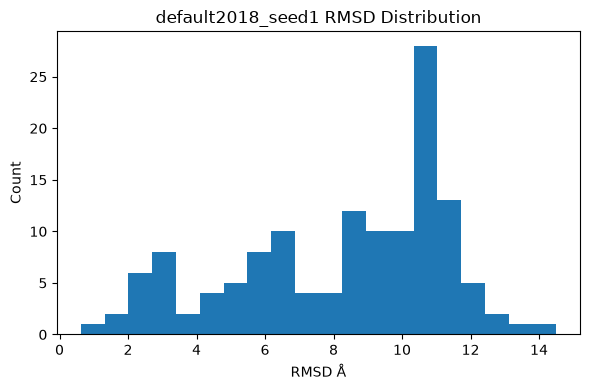

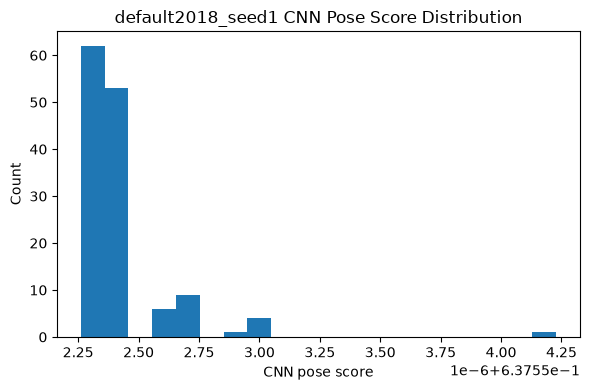

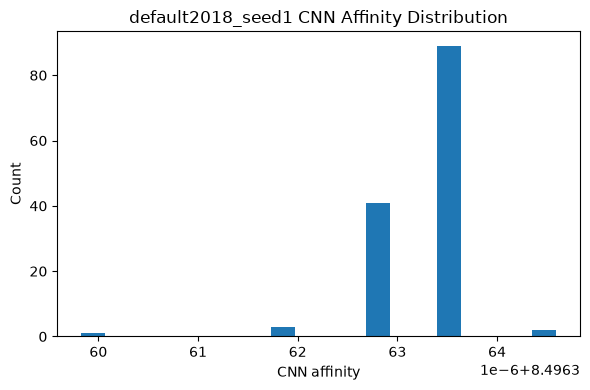

default2018_seed1: Percentage of complexes that has RMSD <= 2 Å: 2.21%


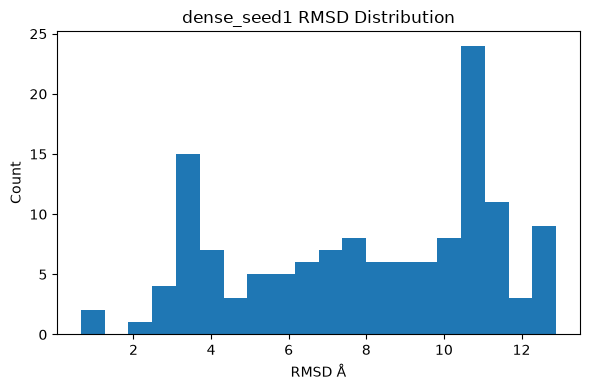

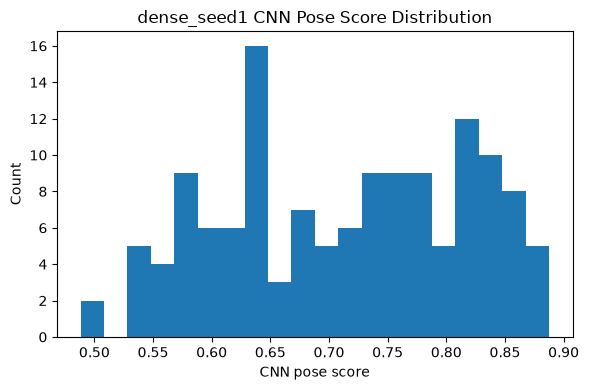

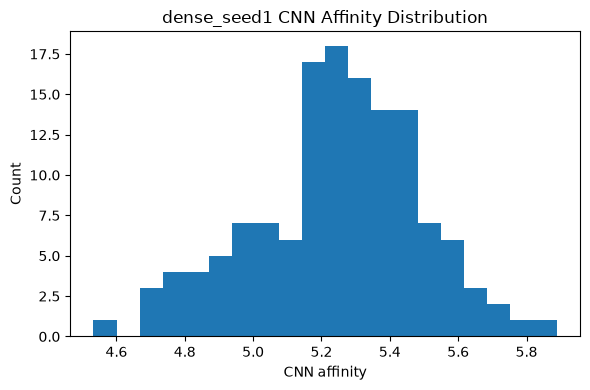

dense_seed1: Percentage of complexes that has RMSD <= 2 Å: 1.47%


In [ ]:
for model_dir in trained_model_dirs:
    model_name = model_dir.name

    #Getting the metrics CSV file.
    metrics_csv = PLOTS_DIR / f"{model_name}_metrics.csv"
    metrics = pd.read_csv(metrics_csv)
    metrics.head()

   #  RMSD distribution plot for retrained GNINA shows distribution of the best pose RMSD values.
   #  vals_rmsd = [v for v in metrics["rmsd"] if pd.notna(v)]
   #  plt.figure(figsize=(6,4))
   #  plt.hist(vals_rmsd, bins=20)
   #  plt.title(f"{model_name} RMSD Distribution")
   #  plt.xlabel("RMSD Å")
   #  plt.ylabel("Count")
   #  plt.tight_layout()
   #  plt.show()

    #Retrained GNINA CNN pose score distribution shows the best CNN pose scores on the proto_test set where higher values mean the pose is more likely to be close to the true binding mode.
    vals_ps = [v for v in metrics["best_cnn_pose_score"] if pd.notna(v)]
    plt.figure(figsize=(6,4))
    plt.hist(vals_ps, bins=20)
    plt.title(f"{model_name} CNN Pose Score Distribution")
    plt.xlabel("CNN pose score")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    #Retrained GNINA CNN affinity distribution indicates in higher values relates to stronger predicted binding affinity between ligand and receptor.
    vals_aff = [v for v in metrics["best_cnn_affinity"] if pd.notna(v)]
    plt.figure(figsize=(6,4))
    plt.hist(vals_aff, bins=20)
    plt.title(f"{model_name} CNN Affinity Distribution")
    plt.xlabel("CNN affinity")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # Generating more detailed RMSD metrics:
    # good_vals = metrics["rmsd"] <= 2.0
    # good_rate = good_vals.mean()
    # print(f"{model_name}: Percentage of complexes that has RMSD <= 2 Å: {good_rate:.2%}")

In [ ]:
#Figures explanations:
#The RMSD histograms for both retrained GNINA models reveal that only a tiny percentage of posebusters complexes fall below similar like proto_test the good pose threshold of 2 Å, and majority are docked with quite high RMSD values. For roughly 1.47% of complexes, the dense_seed1 model achieves an RMSD ≤ 2 Å, whereas default2018_seed1 reaches about 2.21%. Therefore, default2018_seed1 performs better on this Top-1 success criterion.
#The CNN pose score histograms provide an overview of the GNINA CNN's level of accuracy in the top-ranked poses' quality. The majority of posebusters complexes get midrange pose scores rather than continuously very high values for both dense_seed1 and default2018_seed1, suggesting that the network does not substantially favour a small range of obviously "correct" postures. While default2018_seed1 focuses more mass in a small range, that is aligned with its slightly larger fraction of low-RMSD poses and signals that its scores are more adjusted for this dataset, the dense_seed1 model has wider spread of pose scores.
#The expected binding strengths for each complex's optimal poses are displayed in the CNN affinity histograms. The majority of ligands are given comparable affinities despite their varied RMSD values because both models generate relatively narrow affinity distributions. The default2018_seed1 model has a slightly shifted and more concentrated peak that corresponds to its RMSD ≤ 2 Å rate, but the dense_seed1 model's affinities are centred around a single primary peak. These figures indicate that while the total range of predicted affinities is similar between the two models, changes in the training setting primarily impact pose quality (RMSD) and pose-score calibration.

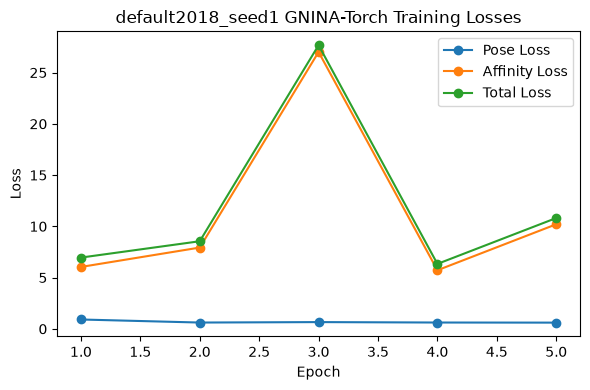

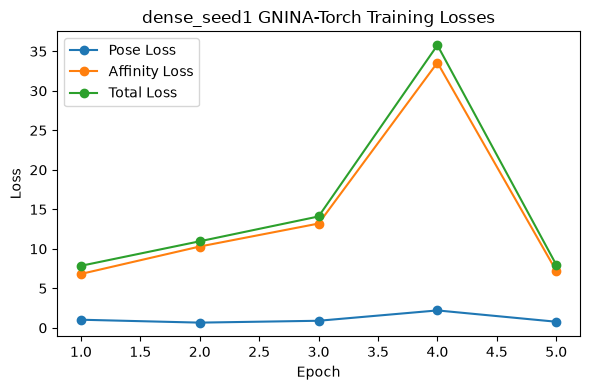

In [ ]:
#GNINA-Torch training and test pose loss plot shows how the pose loss evolves over epochs for the training and the test metrics, which enables whether the retrained model is learning and are there overfittings.
def log_metrics_train(log_fl: Path):
    metrics = {}
    if not log_fl.exists(): # error handling 
        print(f"skipping: training log not found: {log_fl}")
        return metrics

    key_map = { # dict structure
        "Accuracy": "accuracy",
        "Balanced Accuracy": "balanced_accuracy",
        "Pose Loss": "pose_loss",
        "ROC AUC": "roc_auc",
        "MAE": "mae",
        "RMSE": "rmse",
        "Affinity Loss": "affinity_loss",
        "Loss": "loss",
        "Epoch Time": "epoch_time",
        "Elapsed Time": "elapsed_time",
    }

    updated_epch = None

    with log_fl.open(errors="ignore") as f:
        for line in f:
            line = line.strip()

            #using regex expressions for flexibility while parsing metrics.
            train_mtc = re.search(  
                r">>>\s*Train Results\s*-\s*Epoch\[(\d+)\]",
                line,
                re.IGNORECASE,
            )
            if train_mtc: #creating a new dict entry for the metrics of each training epoch, if there is a header line.
                updated_epch = int(train_mtc.group(1))
                metrics[updated_epch] = {}
                continue

            if updated_epch is None:
                continue

            metric_mtch = re.match( #finding out if a metric in the dict is mentioned.
                r"(.+?):\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)",
                line,
            )
            if metric_mtch: #getting the titles of each line and its content values.
                raw_key = metric_mtch.group(1).strip()
                value = float(metric_mtch.group(2))
                if raw_key in key_map: 
                    metrics[updated_epch][key_map[raw_key]] = value

    return metrics

#Iretaring over each trained model directory.
for model_dir in trained_model_dirs: 
    model_name = model_dir.name #dense or default2018 model

    log_fl = model_dir / "training.log"
    metrics_log = log_metrics_train(log_fl)

    epochs = sorted(metrics_log.keys()) #sorting by epoch dict
    pose_loss = [metrics_log[e]["pose_loss"] for e in epochs if "pose_loss" in metrics_log[e]]
    affinity_loss = [metrics_log[e]["affinity_loss"] for e in epochs if "affinity_loss" in metrics_log[e]]
    total_loss = [metrics_log[e]["loss"] for e in epochs if "loss" in metrics_log[e]]

    plt.figure(figsize=(6,4))
    if pose_loss:
        plt.plot(epochs, pose_loss, marker="o", label="Pose Loss")
    if affinity_loss:
        plt.plot(epochs, affinity_loss, marker="o", label="Affinity Loss")
    if total_loss:
        plt.plot(epochs, total_loss, marker="o", label="Total Loss")

    plt.title(f"{model_name} GNINA-Torch Training Losses")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [7]:
#Figures explanation:
#The GNINA-Torch training curves for the dense_seed1 model illustrate the progress of pose loss, affinity loss, and total loss over the course of our five epochs. While affinity and total loss rise rapidly around epoch 4 before declining once more at epoch 5, pose loss remains very low and fluctuates just slightly. This pattern implies that the model may still be under-trained or sensitive to learning-rate and optimisation settings because the brief training session did not reach a stable minimum. Also, dense_seed1's poorer RMSD performance on proto_test may be due to the fact that it hasn't fully converged within this few epochs.
#The default2018_seed1 model exhibits a similar general pattern, with affinity/total loss spiking in the middle of training and pose loss staying low. The curves' amplitude and form, are slightly different from dense_seed1: the ultimate losses are smaller and the primary loss peak happens one epoch earlier. The larger fraction of proto_test complexes with RMSD ≤ 2 Å suggests that default2018_seed1 is learning a little more effectively under the same training schedule. When taken as a whole, the two charts imply that increasing training and fine-tuning hyperparameters could further distinguish the models' performance and lower overall docking losses.

In [ ]:
#Discussion:
#Both models produce low Top-1 success rates (RMSD < 2.0 Å for only a few complexes) on the posebusters benchmark, and the RMSD histograms display extended tails of high-RMSD poses. 
#When we compare posebusters results we can see similar trend with proto_test results. One reason can be we applied the same pipeline, the same metric definitions, same plotting code, and similar model behavior can produce very similar-looking outputs. 

: 